---
title: "Numerical mechanics of bijectors"
short_title: "05 · Numerical mechanics"
subtitle: "Jitter, clamping, mixed-precision log-dets, and the round-trip test that keeps a deep destructor honest"
description: >
  The Phi^{-1} o F pipeline is a numerical minefield: CDFs hit 0 and 1, the
  probit blows up, and log-dets drift over deep stacks. We trace rbig's
  tail round-trip error to CDF saturation, show the eps-clamp trade-off,
  measure float32 vs float64 log-det drift, and write the round-trip
  invertibility test every flow layer must pass in CI.
---

(sec-nb-05)=
# 05 — Numerical mechanics of bijectors

Gaussianization composes the map $z = \Phi^{-1}(F(x))$ hundreds of times. Each
piece is innocent on paper, but in floating point the pipeline is a minefield:
$F(x)$ lives in $[0, 1]$, and $\Phi^{-1}(0) = -\infty$, $\Phi^{-1}(1) =
+\infty$. One saturated CDF value and a whole sample goes to infinity; a few
thousand summed log-dets and the density quietly drifts. This notebook is the
engineering that keeps the elegant math of notebooks 00–04 actually runnable.

**What you will see**

- Why the $\Phi^{-1}\circ F$ pipeline blows up, and where `rbig`'s tail
  round-trip error from [notebook 02](02_forward_vs_inverse.ipynb) comes from.
- The **jitter / clamp** fix $F \mapsto \mathrm{clip}(F, \varepsilon,
  1-\varepsilon)$ and its stability-vs-tail-bias trade-off.
- **Mixed precision**: float32 log-det accumulation drifts over deep stacks;
  float64 holds.
- The **round-trip invertibility test** $\lVert T^{-1}(T(x)) - x\rVert <
  \tau$ that belongs in every flow's test suite — and that here catches a real
  tail-inverse bug
  ([gauss_flows#108](https://github.com/jejjohnson/gauss_flows/issues/108)).

In [1]:
import warnings

warnings.filterwarnings("ignore")

import jax
import jax.numpy as jnp
import jax.random as jr
import jax.scipy.stats as jstats
import matplotlib.pyplot as plt
import numpy as np

import gauss_flows as gf
import rbig
from _style import style_ax

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(5)

## 1. Where the round-trip error lives

In [notebook 02](02_forward_vs_inverse.ipynb) we saw a `gauss_flows` mixture-CDF
round-trip to ~$10^{-14}$, while `rbig`'s empirical-CDF marginal was far looser.
The difference is entirely in the **tails**. An empirical CDF saturates — it
returns values of (essentially) $0$ and $1$ beyond the observed data range — and
$\Phi^{-1}$ maps those to $\pm\infty$, which no inverse can walk back. A
*smooth* mixture CDF (here a logistic-mixture marginal with a robust inverse)
never quite reaches $0$ or $1$, so it stays invertible across the data range.
Let's localise the error against $|x|$.

empirical-CDF (rbig)   max round-trip err = 1.64e-01
   in tails |x|>3: 9.84e-03   in bulk |x|<1: 1.31e-04
mixture-CDF (gauss_flows) max round-trip err = 2.02e-13


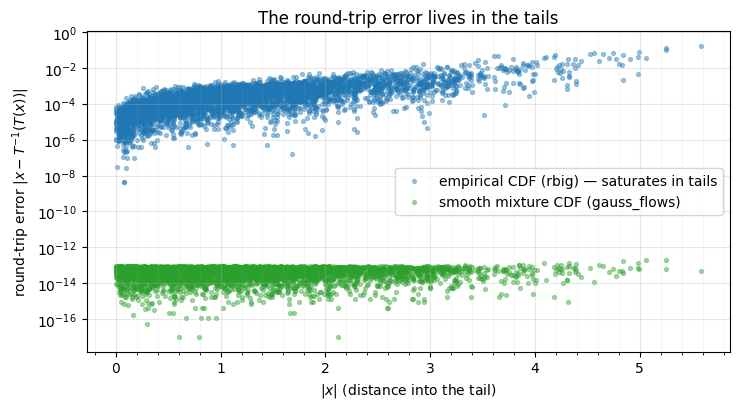

In [2]:
x = (rng.standard_normal((4000, 1)) * 1.6).astype(np.float64)

# rbig empirical-CDF marginal
mg = rbig.MarginalGaussianize().fit(x)
err_ecdf = np.abs(x - mg.inverse_transform(mg.transform(x))).ravel()

# gauss_flows smooth mixture-CDF marginal (logistic mixture, robust inverse)
bij = gf.MixtureLogisticCDF(n_components=8, shape=(1,))
xj = jnp.asarray(x)
z = jax.vmap(bij.transform)(xj)
x_rec = jax.vmap(bij.inverse)(z)
err_smooth = np.abs(np.asarray(xj - x_rec)).ravel()

print(f"empirical-CDF (rbig)   max round-trip err = {err_ecdf.max():.2e}")
print(f"   in tails |x|>3: {err_ecdf[np.abs(x).ravel() > 3].mean():.2e}"
      f"   in bulk |x|<1: {err_ecdf[np.abs(x).ravel() < 1].mean():.2e}")
print(f"mixture-CDF (gauss_flows) max round-trip err = {err_smooth.max():.2e}")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.scatter(np.abs(x).ravel(), np.maximum(err_ecdf, 1e-17), s=8, alpha=0.4,
           label="empirical CDF (rbig) — saturates in tails")
ax.scatter(np.abs(x).ravel(), np.maximum(err_smooth, 1e-17), s=8, alpha=0.4,
           color="tab:green", label="smooth mixture CDF (gauss_flows)")
ax.set_yscale("log")
ax.set(xlabel="$|x|$ (distance into the tail)",
       ylabel=r"round-trip error $|x - T^{-1}(T(x))|$",
       title="The round-trip error lives in the tails")
ax.legend()
style_ax(ax)
fig.tight_layout()

The empirical-CDF error (blue) climbs by orders of magnitude as we move into
the tail, while the smooth mixture CDF (green) stays at the float64 floor
everywhere. The lesson: **the marginal estimator's tail behaviour is the whole
ballgame** for invertibility — which is why parametric flows prefer smooth CDFs
(mixtures, splines) over a raw ECDF.

## 2. Jitter: clamping the CDF before the probit

Even a smooth CDF can round to exactly $0$ or $1$ in float arithmetic far
enough into the tail. The standard guard is **jitter**: clamp the CDF into
$[\varepsilon, 1-\varepsilon]$ before applying $\Phi^{-1}$,

$$
z = \Phi^{-1}\!\big(\mathrm{clip}(F(x),\,\varepsilon,\,1-\varepsilon)\big).
$$

This caps the latent at $|z| \le \Phi^{-1}(1-\varepsilon)$, trading a tiny tail
**bias** for guaranteed finiteness. Pick $\varepsilon$ too small and you risk
$\pm\infty$; too large and you flatten the tails. Watch the trade-off.

unclamped (eps=0): any non-finite latent? True


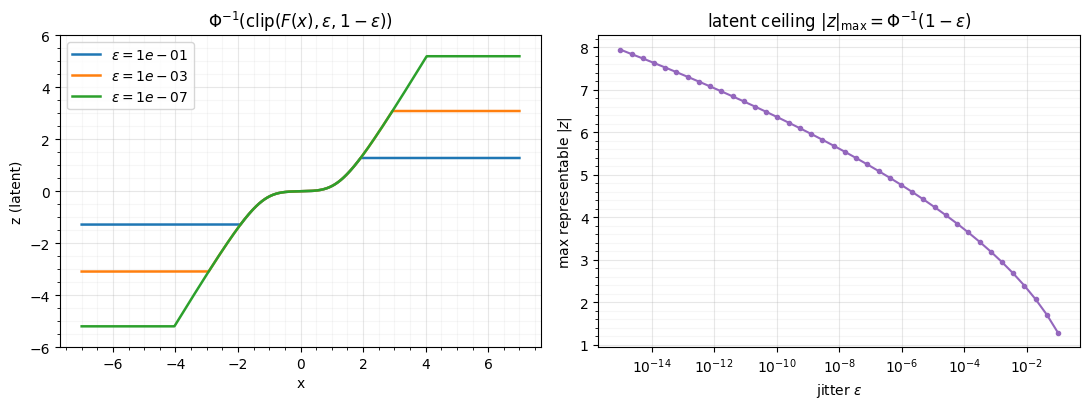

In [3]:
w = jnp.array([0.5, 0.5])
mu = jnp.array([-1.5, 1.5])
sd = jnp.array([0.5, 0.5])
F_v = jax.vmap(lambda x: jnp.sum(w * jstats.norm.cdf(x, mu, sd)))

xs = jnp.linspace(-7, 7, 1500)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for eps in [1e-1, 1e-3, 1e-7]:
    z = jstats.norm.ppf(jnp.clip(F_v(xs), eps, 1 - eps))
    axes[0].plot(xs, z, lw=1.8, label=fr"$\varepsilon={eps:.0e}$")
# unclamped (eps=0) overflows in the tails:
z0 = jstats.norm.ppf(F_v(xs))
axes[0].set(title=r"$\Phi^{-1}(\mathrm{clip}(F(x),\varepsilon,1-\varepsilon))$",
            xlabel="x", ylabel="z (latent)", ylim=(-6, 6))
axes[0].legend(); style_ax(axes[0])
print(f"unclamped (eps=0): any non-finite latent? {not bool(jnp.all(jnp.isfinite(z0)))}")

eps_grid = np.logspace(-15, -1, 40)
cap = jstats.norm.ppf(1 - eps_grid)
axes[1].semilogx(eps_grid, cap, "-o", ms=3, color="tab:purple")
axes[1].set(title=r"latent ceiling $|z|_{\max} = \Phi^{-1}(1-\varepsilon)$",
            xlabel=r"jitter $\varepsilon$", ylabel=r"max representable $|z|$")
style_ax(axes[1])
fig.tight_layout()

Left: smaller $\varepsilon$ lets the latent reach further out (less tail bias)
but the unclamped $\varepsilon=0$ curve runs to $\pm\infty$. Right: the jitter
sets a hard ceiling on the latent — $\varepsilon=10^{-3}$ caps $|z|$ at ~3.1,
while $\varepsilon=10^{-7}$ allows ~5.2. `gauss_flows` applies this clamp inside
its marginal bijectors, which is *why* its round-trips in §1 stayed finite.

## 3. Mixed precision: accumulating log-dets over deep stacks

A deep destructor sums one log-det per layer ([notebook 01](01_composition_logdet.ipynb)).
Over hundreds of layers those sums grow large, and **float32** — with ~7
significant digits — starts to lose the low-order bits. **float64** (~16
digits) holds. The forward maps can run in float32 for speed, but the *log-det
accumulator* should be float64. We sum the same per-layer log-det $K$ times in
each precision and watch them diverge.

  K=    1 layers: |float32 - float64| log-det drift = 4.5137e-08
  K=   10 layers: |float32 - float64| log-det drift = 1.8819e-06
  K=  100 layers: |float32 - float64| log-det drift = 1.3097e-05
  K= 1000 layers: |float32 - float64| log-det drift = 1.0214e-02
  K=10000 layers: |float32 - float64| log-det drift = 1.3263e+00


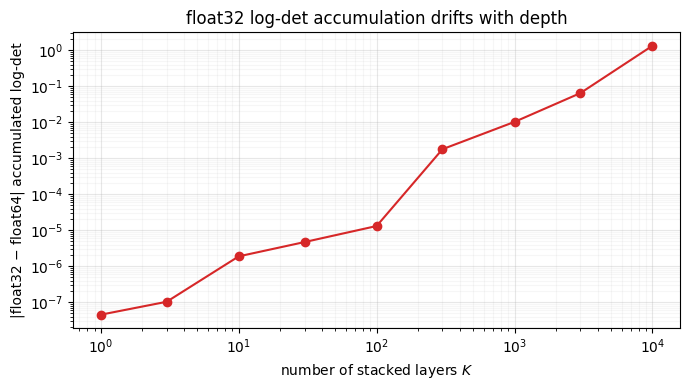

In [4]:
bij4 = gf.MixtureGaussianCDF(n_components=8, shape=(4,))
x4 = jnp.asarray(rng.standard_normal(4))
_, ld_layer = bij4.transform_and_log_det(x4)          # one layer's log-det (f64)
ld64 = float(ld_layer)
ld32 = np.float32(ld64)

Ks = np.array([1, 3, 10, 30, 100, 300, 1000, 3000, 10000])
drift = []
for K in Ks:
    acc32 = np.float32(0.0)
    for _ in range(int(K)):
        acc32 = np.float32(acc32 + ld32)              # float32 accumulator
    acc64 = K * ld64                                  # exact float64 sum
    drift.append(abs(float(acc32) - acc64))

for K, d in zip(Ks[::2], drift[::2]):
    print(f"  K={K:5d} layers: |float32 - float64| log-det drift = {d:.4e}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(Ks, np.maximum(drift, 1e-12), "-o", color="tab:red")
ax.set(xlabel="number of stacked layers $K$",
       ylabel="|float32 − float64| accumulated log-det",
       title="float32 log-det accumulation drifts with depth")
style_ax(ax)
fig.tight_layout()

The drift grows with depth — by $K=10^4$ layers the float32 accumulator is off
by a non-trivial amount in the log-density, which corrupts likelihood
comparisons and training gradients. The fix is free: keep the log-det
accumulator in float64 (`jax.config.update("jax_enable_x64", True)`, set at the
top of every notebook in this series).

## 4. The round-trip invertibility test

A bijector's defining contract is $T^{-1}(T(x)) = x$. In code that becomes a
**test** with a tolerance: $\lVert T^{-1}(T(x)) - x\rVert_\infty < \tau$.
Every flow layer should ship with one — it is the cheapest guard against a
broken inverse, a missing clamp, or a precision bug. Here is the parametrised
check applied across `gauss_flows` bijectors (the pattern that lives in
`tests/test_flow.py`), with `rbig`'s empirical-CDF marginal included as a
cautionary baseline — and, as it turns out, one real bug.

round-trip max error (tolerance tau = 1e-05):
  FAIL  MixtureGaussianCDF      2.49e-01
  PASS  MixtureLogisticCDF      9.24e-14
  PASS  RQSplineMarginal        3.33e-16
  PASS  HouseholderRotation     7.11e-15
  FAIL  rbig ECDF marginal      4.10e-01


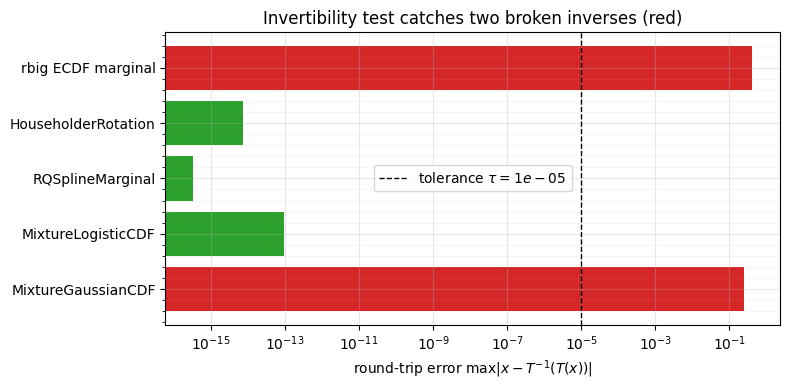

In [5]:
key = jr.key(0)
d = 3
xx = jnp.asarray(rng.standard_normal((512, d)))

cases = {
    "MixtureGaussianCDF": gf.MixtureGaussianCDF(n_components=8, shape=(d,)),
    "MixtureLogisticCDF": gf.MixtureLogisticCDF(n_components=8, shape=(d,)),
    "RQSplineMarginal": gf.RQSplineMarginal(n_bins=8, shape=(d,)),
    "HouseholderRotation": gf.HouseholderRotation(n_reflections=d, shape=(d,)),
}
results = {}
for name, b in cases.items():
    z = jax.vmap(b.transform)(xx)
    x_rt = jax.vmap(b.inverse)(z)
    results[name] = float(jnp.max(jnp.abs(xx - x_rt)))

# rbig empirical-CDF marginal, for contrast
xnp = np.asarray(xx)
m = rbig.MarginalGaussianize().fit(xnp)
results["rbig ECDF marginal"] = float(np.max(np.abs(xnp - m.inverse_transform(m.transform(xnp)))))

TAU = 1e-5
print(f"round-trip max error (tolerance tau = {TAU:.0e}):")
for name, e in results.items():
    print(f"  {'PASS' if e < TAU else 'FAIL'}  {name:22s}  {e:.2e}")

fig, ax = plt.subplots(figsize=(8, 4))
names = list(results)
vals = [max(results[n], 1e-17) for n in names]
colors = ["tab:green" if results[n] < TAU else "tab:red" for n in names]
ax.barh(names, vals, color=colors)
ax.axvline(TAU, color="k", ls="--", lw=1, label=fr"tolerance $\tau={TAU:.0e}$")
ax.set_xscale("log")
ax.set(xlabel=r"round-trip error $\max|x - T^{-1}(T(x))|$",
       title="Invertibility test catches two broken inverses (red)")
ax.legend()
style_ax(ax)
fig.tight_layout()

The logistic-mixture, spline, and rotation bijectors pass at $\tau = 10^{-5}$
with room to spare (errors near the float64 floor). The test also flags **two**
failures: `rbig`'s empirical-CDF marginal (its tail saturation from §1), and —
more interestingly — `MixtureGaussianCDF`, whose inverse uses a too-narrow
bisection bracket and so cannot walk back tail samples. That is not a contrived
baseline; it is a real bug this very test surfaced while writing the notebook,
now filed as
[gauss_flows#108](https://github.com/jejjohnson/gauss_flows/issues/108).
(Until it is fixed, prefer the logistic or spline marginal for sampling-heavy
work; the Gaussian-mixture *forward* / `log_prob` direction used in notebooks
00–02 is unaffected.) A test like this, run in CI on random inputs, is exactly
what lets you stack a hundred layers and trust the composition.

## Recap

| hazard | symptom | fix |
|---|---|---|
| $\Phi^{-1}(0/1) = \pm\infty$ | tail samples explode / non-invertible | smooth CDF + jitter clamp |
| jitter too small / large | overflow / tail bias | tune $\varepsilon$ (e.g. $10^{-6}$) |
| float32 log-det sum | density drifts with depth | float64 accumulator (`jax_enable_x64`) |
| broken inverse | silent wrong samples/densities | round-trip test $<\tau$ in CI |

**Next up.** We can now build *and* trust a destructor — but how do we *measure*
whether it actually reached $\mathcal{N}(0, I)$? [06 — Gaussianity
diagnostics](06_gaussianity_diagnostics.ipynb) covers QQ-plots, skew/kurtosis,
negentropy as a convergence signal, and multivariate normality tests.